# 02 — Data Preparation and Pipeline

**SDC Master's Final Project — soccernet-setpiece-vision**

CRISP-DM phase 3 (Data Preparation). Builds the CV pipeline that turns broadcast frames into metric-pitch player coordinates for set pieces.

**Two parallel tracks per clip:**
- **Pipeline:** YOLOv8x player detection + KMeans-HSV team assignment + homography (estimated from SoccerNet GSR pitch-line annotations) → metric pitch (105 × 68 m).
- **Ground truth:** parse SoccerNet GSR `bbox_pitch` directly (already metric, centred origin). Re-centred to (0–105, 0–68).

**Scope:** all clips across train/valid/test/challenge whose `info.action_class` is `Corner` or `Direct free-kick`. One frame per clip extracted at `info.action_position` (the action moment).

**Note:** The pipeline reuses GT pitch-line annotations to estimate the homography. Fully automated pitch-line detection is out of scope for this notebook; this is a documented simplification. Player detection and team assignment remain fully independent of GT.

## 0. Setup and Imports

In [1]:
import json
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from ultralytics import YOLO
from mplsoccer import Pitch

warnings.filterwarnings("ignore", category=UserWarning)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

GSR_ROOT = Path("/Volumes/MPH-ExternalStorage/soccernet-gsr/gamestate-2024")
SPLITS = ["train", "valid", "test", "challenge"]
TARGET_ACTIONS = {"Corner", "Direct free-kick"}

PITCH_LENGTH_M = 105.0
PITCH_WIDTH_M = 68.0
FRAME_W = 1920
FRAME_H = 1080

YOLO_WEIGHTS = "yolov8x.pt"
YOLO_PERSON_CLASS = 0  # COCO class 0 = person
YOLO_CONF = 0.40

DEVICE = "mps"  # Apple Silicon MPS; falls back to cpu inside ultralytics if unavailable

assert GSR_ROOT.exists(), f"SoccerNet GSR not mounted: {GSR_ROOT}"
print(f"GSR root: {GSR_ROOT}")
print(f"Outputs : {OUTPUTS_DIR}")

GSR root: /Volumes/MPH-ExternalStorage/soccernet-gsr/gamestate-2024
Outputs : /Users/mph/Dev/itzmore-mph/MAIS-projects/final-master-project/soccernet-setpiece-vision/outputs


## 1. Discover Set-Piece Clips

Scan all four splits for `info.action_class in {Corner, Direct free-kick}`.

In [2]:
def discover_setpiece_clips(gsr_root: Path, splits: list[str], target_actions: set[str]) -> pd.DataFrame:
    rows = []
    for split in splits:
        split_dir = gsr_root / split
        if not split_dir.is_dir():
            continue
        for clip_dir in sorted(split_dir.glob("SNGS-*")):
            label_path = clip_dir / "Labels-GameState.json"
            if not label_path.is_file():
                continue
            try:
                info = json.load(open(label_path))["info"]
            except Exception:
                continue
            if info.get("action_class") in target_actions:
                rows.append({
                    "split": split,
                    "clip_id": clip_dir.name,
                    "clip_path": str(clip_dir),
                    "action_class": info["action_class"],
                    "action_position": int(info.get("action_position", 375)),
                })
    return pd.DataFrame(rows)


clips = discover_setpiece_clips(GSR_ROOT, SPLITS, TARGET_ACTIONS)
print(f"Set-piece clips found: {len(clips)}")
print(clips["action_class"].value_counts())
clips.head()

Set-piece clips found: 33
action_class
Corner              17
Direct free-kick    16
Name: count, dtype: int64


,split,clip_id,clip_path,action_class,action_position
0,train,SNGS-066,/Volumes/MPH-ExternalStorage/soccernet-gsr/gam...,Direct free-kick,1781009
1,train,SNGS-067,/Volumes/MPH-ExternalStorage/soccernet-gsr/gam...,Corner,2577866
2,train,SNGS-071,/Volumes/MPH-ExternalStorage/soccernet-gsr/gam...,Direct free-kick,509004
3,train,SNGS-075,/Volumes/MPH-ExternalStorage/soccernet-gsr/gam...,Corner,1624251
4,train,SNGS-100,/Volumes/MPH-ExternalStorage/soccernet-gsr/gam...,Direct free-kick,768740


## 2. Helpers

### 2.1 Homography from pitch-line annotations

SoccerNet GSR labels each pitch line as a polyline in normalised image coordinates (x, y in [0, 1]). A small set of well-known intersections gives ≥ 4 image↔pitch correspondences, sufficient for a planar homography via OpenCV's RANSAC.

We use intersections of long, well-detected lines (`Side line top`, `Side line bottom`, `Side line left`, `Side line right`, `Middle line`) at the corners and centre.

In [3]:
# Pitch geometry (metres, origin = top-left, x along length 0..105, y across width 0..68)
PB_TOP = 34.0 - 40.32 / 2     # 13.84
PB_BOT = 34.0 + 40.32 / 2     # 54.16
SIX_TOP = 34.0 - 18.32 / 2    # 24.84
SIX_BOT = 34.0 + 18.32 / 2    # 43.16
GOAL_TOP = 34.0 - 7.32 / 2    # 30.34
GOAL_BOT = 34.0 + 7.32 / 2    # 37.66
PB_DEPTH = 16.5
SIX_DEPTH = 5.5
L = PITCH_LENGTH_M
W = PITCH_WIDTH_M

# Known line-line intersections in pitch metres. Lines named per SoccerNet GSR convention.
INTERSECTIONS_M = {
    # outer corners
    ("Side line top",    "Side line left"):   (0.0, 0.0),
    ("Side line top",    "Side line right"):  (L, 0.0),
    ("Side line bottom", "Side line left"):   (0.0, W),
    ("Side line bottom", "Side line right"):  (L, W),
    # halfway
    ("Side line top",    "Middle line"):      (L / 2, 0.0),
    ("Side line bottom", "Middle line"):      (L / 2, W),
    # left penalty box
    ("Side line left",        "Big rect. left top"):     (0.0, PB_TOP),
    ("Side line left",        "Big rect. left bottom"):  (0.0, PB_BOT),
    ("Big rect. left top",    "Big rect. left main"):    (PB_DEPTH, PB_TOP),
    ("Big rect. left bottom", "Big rect. left main"):    (PB_DEPTH, PB_BOT),
    # left six-yard
    ("Side line left",          "Small rect. left top"):     (0.0, SIX_TOP),
    ("Side line left",          "Small rect. left bottom"):  (0.0, SIX_BOT),
    ("Small rect. left top",    "Small rect. left main"):    (SIX_DEPTH, SIX_TOP),
    ("Small rect. left bottom", "Small rect. left main"):    (SIX_DEPTH, SIX_BOT),
    # left goal posts (post lines are short verticals at x=0)
    ("Side line left", "Goal left post left"):  (0.0, GOAL_TOP),
    ("Side line left", "Goal left post right"): (0.0, GOAL_BOT),
    # right penalty box
    ("Side line right",        "Big rect. right top"):     (L, PB_TOP),
    ("Side line right",        "Big rect. right bottom"):  (L, PB_BOT),
    ("Big rect. right top",    "Big rect. right main"):    (L - PB_DEPTH, PB_TOP),
    ("Big rect. right bottom", "Big rect. right main"):    (L - PB_DEPTH, PB_BOT),
    # right six-yard
    ("Side line right",          "Small rect. right top"):     (L, SIX_TOP),
    ("Side line right",          "Small rect. right bottom"):  (L, SIX_BOT),
    ("Small rect. right top",    "Small rect. right main"):    (L - SIX_DEPTH, SIX_TOP),
    ("Small rect. right bottom", "Small rect. right main"):    (L - SIX_DEPTH, SIX_BOT),
    # right goal posts
    ("Side line right", "Goal right post left"):  (L, GOAL_TOP),
    ("Side line right", "Goal right post right"): (L, GOAL_BOT),
}

# Lines we attempt to fit in image space
CANDIDATE_LINES = sorted({n for pair in INTERSECTIONS_M.keys() for n in pair})


def line_polyline_to_image(pts_norm: list[dict]) -> np.ndarray | None:
    """Convert normalised polyline points to pixel coords. Returns Nx2 array or None."""
    if not pts_norm or len(pts_norm) < 2:
        return None
    arr = np.array([[p["x"] * FRAME_W, p["y"] * FRAME_H] for p in pts_norm], dtype=np.float32)
    return arr


def fit_line_2d(pts: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Fit a 2D line through points, return (point_on_line, unit_direction)."""
    vx, vy, x0, y0 = cv2.fitLine(pts.astype(np.float32), cv2.DIST_L2, 0, 0.01, 0.01).flatten()
    return np.array([x0, y0], dtype=np.float64), np.array([vx, vy], dtype=np.float64)


def line_intersection(p1, d1, p2, d2) -> np.ndarray | None:
    """Intersect two parametric lines p + t*d. Returns 2-vector or None if parallel."""
    A = np.column_stack([d1, -d2])
    if abs(np.linalg.det(A)) < 1e-6:
        return None
    t = np.linalg.solve(A, (p2 - p1))
    return p1 + t[0] * d1


def homography_from_pitch_lines(pitch_ann_lines: dict) -> np.ndarray | None:
    """Estimate pixel->pitch homography from a frame's pitch-line annotations.

    Returns 3x3 H mapping image (px, py, 1) -> pitch (mx, my, 1) in metres,
    or None if too few intersections are recoverable.
    """
    fitted = {}
    for name in CANDIDATE_LINES:
        if name in pitch_ann_lines:
            pts = line_polyline_to_image(pitch_ann_lines[name])
            if pts is not None and len(pts) >= 2:
                fitted[name] = fit_line_2d(pts)
    src_pts, dst_pts = [], []
    for (a, b), pitch_xy in INTERSECTIONS_M.items():
        if a in fitted and b in fitted:
            inter = line_intersection(fitted[a][0], fitted[a][1], fitted[b][0], fitted[b][1])
            if inter is not None and -200 <= inter[0] <= FRAME_W + 200 and -200 <= inter[1] <= FRAME_H + 200:
                src_pts.append(inter)
                dst_pts.append(pitch_xy)
    if len(src_pts) < 4:
        return None
    src = np.array(src_pts, dtype=np.float64)
    dst = np.array(dst_pts, dtype=np.float64)
    H, _ = cv2.findHomography(src, dst, method=cv2.RANSAC, ransacReprojThreshold=15.0)
    return H


def project_points(H: np.ndarray, pts_xy: np.ndarray) -> np.ndarray:
    """Apply 3x3 homography to Nx2 pixel points, return Nx2 metric points."""
    if len(pts_xy) == 0:
        return pts_xy
    homo = np.column_stack([pts_xy, np.ones(len(pts_xy))])
    out = (H @ homo.T).T
    return out[:, :2] / out[:, 2:3]


### 2.2 KMeans team assignment via jersey HSV

In [4]:
def jersey_hsv(image_bgr: np.ndarray, bbox_xywh: np.ndarray) -> np.ndarray:
    """Mean HSV of the central torso region of a bbox. Returns 3-vector."""
    x, y, w, h = bbox_xywh
    x1 = int(x + 0.25 * w); x2 = int(x + 0.75 * w)
    y1 = int(y + 0.15 * h); y2 = int(y + 0.45 * h)
    x1, y1 = max(0, x1), max(0, y1)
    x2 = min(image_bgr.shape[1] - 1, x2)
    y2 = min(image_bgr.shape[0] - 1, y2)
    if x2 <= x1 or y2 <= y1:
        return np.array([np.nan, np.nan, np.nan])
    crop = image_bgr[y1:y2, x1:x2]
    hsv = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV)
    return hsv.reshape(-1, 3).mean(axis=0)


def _is_ref_like(hsv_centroid: np.ndarray) -> bool:
    """Heuristic: ref kits typically yellow/green (H 25-65) or near-black (V<60) or low-sat grey."""
    h, s, v = float(hsv_centroid[0]), float(hsv_centroid[1]), float(hsv_centroid[2])
    if 20 <= h <= 65 and s > 80:        # yellow / green ref
        return True
    if v < 50:                           # very dark (black ref)
        return True
    return False


def assign_teams_kmeans(hsv_features: np.ndarray, k: int = 3, drop_frac: float = 0.15) -> np.ndarray:
    """KMeans with k=3. Drop smallest cluster only if (a) it's < drop_frac of total
    OR (b) its centroid looks ref-like. Otherwise, fall back to k=2 mapping.
    Returns labels in {0, 1} for kept players; dropped/NaN -> -1.
    """
    valid = ~np.isnan(hsv_features).any(axis=1)
    labels = np.full(len(hsv_features), -1, dtype=int)
    n_valid = int(valid.sum())
    if n_valid < 2:
        return labels
    if n_valid < k:
        km = KMeans(n_clusters=2, n_init=10, random_state=42)
        labels[valid] = km.fit_predict(hsv_features[valid])
        return labels

    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    raw = km.fit_predict(hsv_features[valid])
    sizes = np.bincount(raw, minlength=k)
    centroids = km.cluster_centers_
    order = np.argsort(-sizes)  # large -> small
    smallest = order[-1]

    drop_smallest = (sizes[smallest] / n_valid < drop_frac) or _is_ref_like(centroids[smallest])

    if drop_smallest:
        keep = {order[0]: 0, order[1]: 1}
        remap = np.array([keep.get(c, -1) for c in raw])
    else:
        # k=2 fallback
        km2 = KMeans(n_clusters=2, n_init=10, random_state=42)
        remap = km2.fit_predict(hsv_features[valid])
    labels[valid] = remap
    return labels


### 2.3 YOLOv8 player detector

In [5]:
yolo = YOLO(YOLO_WEIGHTS)
print(f"YOLO weights: {YOLO_WEIGHTS}  |  device: {DEVICE}")


def detect_players(yolo_model, image_bgr: np.ndarray) -> np.ndarray:
    """Run YOLOv8 on a single frame, return Nx5 [x, y, w, h, conf] for class=person."""
    res = yolo_model.predict(source=image_bgr, conf=YOLO_CONF, classes=[YOLO_PERSON_CLASS],
                             device=DEVICE, verbose=False)[0]
    if res.boxes is None or len(res.boxes) == 0:
        return np.zeros((0, 5), dtype=np.float32)
    xyxy = res.boxes.xyxy.cpu().numpy()
    conf = res.boxes.conf.cpu().numpy()
    x = xyxy[:, 0]; y = xyxy[:, 1]
    w = xyxy[:, 2] - xyxy[:, 0]
    h = xyxy[:, 3] - xyxy[:, 1]
    return np.column_stack([x, y, w, h, conf]).astype(np.float32)

YOLO weights: yolov8x.pt  |  device: mps


## 3. Process Set-Piece Clips

Per clip: load frame at `action_position`, run pipeline, parse GT. Both rows tagged with `clip_id`, `frame_idx`, `action_class`, `track` ∈ {pipeline, gt}.

In [6]:
def load_frame(clip_path: Path, frame_idx: int) -> np.ndarray | None:
    """Load 1-based JPEG frame from img1/. Returns BGR ndarray."""
    fname = f"{frame_idx:06d}.jpg"
    fp = clip_path / "img1" / fname
    if not fp.is_file():
        return None
    return cv2.imread(str(fp))


def parse_gt_frame(labels: dict, image_id: str) -> list[dict]:
    """Extract GT player rows for a given image_id from Labels-GameState.json.
    Returns list with metric pitch coords (re-centred to 0..L, 0..W).
    """
    rows = []
    for a in labels["annotations"]:
        if a.get("image_id") != image_id:
            continue
        if a.get("category_id") not in (1, 2):  # 1=player, 2=goalkeeper
            continue
        bp = a.get("bbox_pitch")
        if not bp:
            continue
        x_centred = bp.get("x_bottom_middle")
        y_centred = bp.get("y_bottom_middle")
        if x_centred is None or y_centred is None:
            continue
        rows.append({
            "x_m": float(x_centred) + PITCH_LENGTH_M / 2,
            "y_m": float(y_centred) + PITCH_WIDTH_M / 2,
            "team": a["attributes"].get("team"),
            "role": a["attributes"].get("role"),
            "track_id": a.get("track_id"),
        })
    return rows


def find_pitch_ann(labels: dict, image_id: str) -> dict | None:
    for a in labels["annotations"]:
        if a.get("image_id") == image_id and a.get("category_id") == 5:
            return a.get("lines", {})
    return None


def image_id_for_frame(labels: dict, frame_idx: int) -> str | None:
    target = f"{frame_idx:06d}.jpg"
    for img in labels["images"]:
        if img.get("file_name") == target:
            return img.get("image_id")
    return None

In [7]:
pipeline_rows = []
gt_rows = []
skipped = []

FRAME_WINDOW = 15  # sample +/- 15 frames around action_position

for i, clip in clips.iterrows():
    clip_path = Path(clip["clip_path"])
    label_path = clip_path / "Labels-GameState.json"
    try:
        labels = json.load(open(label_path))
    except Exception as e:
        skipped.append((clip["clip_id"], -1, f"labels: {e}"))
        continue

    n_frames = len(labels["images"])
    centre = max(1, min(int(clip["action_position"]), n_frames))
    lo = max(1, centre - FRAME_WINDOW)
    hi = min(n_frames, centre + FRAME_WINDOW)

    n_processed = 0
    n_homog_fail = 0

    for frame_idx in range(lo, hi + 1):
        image_id = image_id_for_frame(labels, frame_idx)
        if image_id is None:
            continue

        frame = load_frame(clip_path, frame_idx)
        if frame is None:
            continue

        pitch_lines = find_pitch_ann(labels, image_id)
        H = homography_from_pitch_lines(pitch_lines) if pitch_lines else None
        if H is None:
            n_homog_fail += 1
            continue

        # ---- Pipeline track ----
        dets = detect_players(yolo, frame)
        if len(dets) > 0:
            feet = np.column_stack([dets[:, 0] + dets[:, 2] / 2, dets[:, 1] + dets[:, 3]])
            pitch_xy = project_points(H, feet)
            hsv = np.array([jersey_hsv(frame, dets[k, :4]) for k in range(len(dets))])
            team_lbl = assign_teams_kmeans(hsv, k=2)
            for k in range(len(dets)):
                x_m, y_m = float(pitch_xy[k, 0]), float(pitch_xy[k, 1])
                if not (0 <= x_m <= PITCH_LENGTH_M and 0 <= y_m <= PITCH_WIDTH_M):
                    continue
                if int(team_lbl[k]) < 0:
                    continue  # drop refs/outliers (smallest KMeans cluster)
                pipeline_rows.append({
                    "split": clip["split"], "clip_id": clip["clip_id"],
                    "action_class": clip["action_class"], "frame_idx": frame_idx,
                    "x_m": x_m, "y_m": y_m,
                    "team_kmeans": int(team_lbl[k]),
                    "conf": float(dets[k, 4]),
                    "hsv_h": float(hsv[k, 0]), "hsv_s": float(hsv[k, 1]), "hsv_v": float(hsv[k, 2]),
                })

        # ---- GT track ----
        for r in parse_gt_frame(labels, image_id):
            gt_rows.append({
                "split": clip["split"], "clip_id": clip["clip_id"],
                "action_class": clip["action_class"], "frame_idx": frame_idx,
                **r,
            })

        n_processed += 1

    if n_processed == 0:
        skipped.append((clip["clip_id"], centre, f"all {hi - lo + 1} frames failed homography"))

    if (i + 1) % 5 == 0:
        print(f"  clips {i+1}/{len(clips)}  |  pipeline rows: {len(pipeline_rows)}  |  gt rows: {len(gt_rows)}")

print(f"\nDone. Pipeline rows: {len(pipeline_rows)}  |  GT rows: {len(gt_rows)}  |  Clips fully skipped: {len(skipped)}")
for c, fr, w in skipped[:10]:
    print(f"  skipped {c} (centre {fr}): {w}")


  clips 5/33  |  pipeline rows: 1090  |  gt rows: 1243


  clips 10/33  |  pipeline rows: 1202  |  gt rows: 1355


  clips 15/33  |  pipeline rows: 1774  |  gt rows: 1923


  clips 20/33  |  pipeline rows: 2570  |  gt rows: 2669


  clips 25/33  |  pipeline rows: 2997  |  gt rows: 3092


  clips 30/33  |  pipeline rows: 3766  |  gt rows: 3895



Done. Pipeline rows: 4146  |  GT rows: 4295  |  Clips fully skipped: 13
  skipped SNGS-103 (centre 750): all 16 frames failed homography
  skipped SNGS-109 (centre 750): all 16 frames failed homography
  skipped SNGS-110 (centre 750): all 16 frames failed homography
  skipped SNGS-154 (centre 750): all 16 frames failed homography
  skipped SNGS-167 (centre 750): all 16 frames failed homography
  skipped SNGS-025 (centre 750): all 16 frames failed homography
  skipped SNGS-042 (centre 750): all 16 frames failed homography
  skipped SNGS-057 (centre 750): all 16 frames failed homography
  skipped SNGS-093 (centre 750): all 16 frames failed homography
  skipped SNGS-116 (centre 750): all 16 frames failed homography


## 4. Build DataFrames

In [8]:
pipeline_df = pd.DataFrame(pipeline_rows)
gt_df = pd.DataFrame(gt_rows)
print("pipeline_df:", pipeline_df.shape)
print("gt_df      :", gt_df.shape)
pipeline_df.head()

pipeline_df: (4146, 11)
gt_df      : (4295, 9)


,split,clip_id,action_class,frame_idx,x_m,y_m,team_kmeans,conf,hsv_h,hsv_s,hsv_v
0,train,SNGS-066,Direct free-kick,735,77.314579,35.911788,1,0.889180,63.212101,49.042553,204.674867
1,train,SNGS-066,Direct free-kick,735,84.673553,32.281038,1,0.883930,55.738213,73.988834,191.939206
2,train,SNGS-066,Direct free-kick,735,83.655235,27.400030,0,0.853551,49.076923,123.189904,164.585337
3,train,SNGS-066,Direct free-kick,735,67.844605,19.113899,1,0.830041,81.013258,71.102273,177.181818
4,train,SNGS-066,Direct free-kick,735,62.865523,15.005539,0,0.829923,51.618750,101.995833,148.243750


In [9]:
gt_df.head()

,split,clip_id,action_class,frame_idx,x_m,y_m,team,role,track_id
0,train,SNGS-066,Direct free-kick,735,64.868946,27.409441,right,player,4
1,train,SNGS-066,Direct free-kick,735,77.556595,35.506850,right,player,6
2,train,SNGS-066,Direct free-kick,735,76.187156,25.253708,right,player,7
3,train,SNGS-066,Direct free-kick,735,71.473101,12.849470,right,player,8
4,train,SNGS-066,Direct free-kick,735,59.712886,47.126080,right,player,9


## 5. Sanity Visualisations

### 5.1 Pipeline vs GT — combined scatter on metric pitch

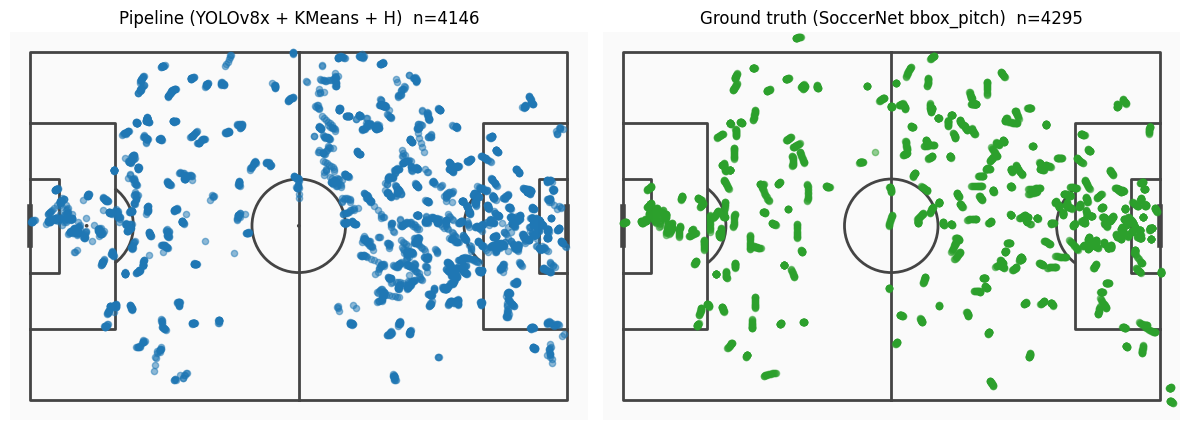

In [10]:
pitch = Pitch(pitch_type="custom", pitch_length=PITCH_LENGTH_M, pitch_width=PITCH_WIDTH_M,
              line_color="#444", pitch_color="#fafafa")
fig, axes = pitch.draw(figsize=(12, 6), nrows=1, ncols=2)
if not pipeline_df.empty:
    pitch.scatter(pipeline_df["x_m"], pipeline_df["y_m"], ax=axes[0], s=20, alpha=0.5, color="#1f77b4")
axes[0].set_title(f"Pipeline (YOLOv8x + KMeans + H)  n={len(pipeline_df)}")
if not gt_df.empty:
    pitch.scatter(gt_df["x_m"], gt_df["y_m"], ax=axes[1], s=20, alpha=0.5, color="#2ca02c")
axes[1].set_title(f"Ground truth (SoccerNet bbox_pitch)  n={len(gt_df)}")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_pipeline_vs_gt_scatter.png", dpi=150)
plt.show()

### 5.2 Players-per-frame distribution

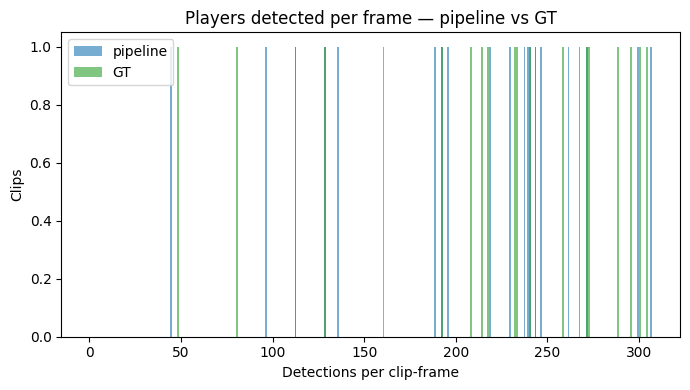

pipeline mean: 207.3   GT mean: 214.8


In [11]:
if not pipeline_df.empty and not gt_df.empty:
    pl_count = pipeline_df.groupby("clip_id").size()
    gt_count = gt_df.groupby("clip_id").size()
    fig, ax = plt.subplots(figsize=(7, 4))
    bins = range(0, max(pl_count.max(), gt_count.max()) + 2)
    ax.hist(pl_count, bins=bins, alpha=0.6, label="pipeline", color="#1f77b4")
    ax.hist(gt_count, bins=bins, alpha=0.6, label="GT", color="#2ca02c")
    ax.set_xlabel("Detections per clip-frame")
    ax.set_ylabel("Clips")
    ax.set_title("Players detected per frame — pipeline vs GT")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "06_players_per_frame_dist.png", dpi=150)
    plt.show()
    print(f"pipeline mean: {pl_count.mean():.1f}   GT mean: {gt_count.mean():.1f}")

## 6. Save Outputs

In [12]:
pipeline_path = OUTPUTS_DIR / "detections_pipeline.parquet"
gt_path = OUTPUTS_DIR / "detections_gt.parquet"
pipeline_df.to_parquet(pipeline_path, engine="pyarrow", index=False)
gt_df.to_parquet(gt_path, engine="pyarrow", index=False)

print(f"Pipeline rows : {len(pipeline_df):>5}  ({pipeline_path.stat().st_size / 1024:.1f} KB)")
print(f"GT rows       : {len(gt_df):>5}  ({gt_path.stat().st_size / 1024:.1f} KB)")
print(f"Clips processed: {clips.shape[0] - len(skipped)} / {len(clips)}")
print(f"Saved to       : {OUTPUTS_DIR}")

Pipeline rows :  4146  (227.7 KB)
GT rows       :  4295  (88.9 KB)
Clips processed: 20 / 33
Saved to       : /Users/mph/Dev/itzmore-mph/MAIS-projects/final-master-project/soccernet-setpiece-vision/outputs


### Next Steps
- Notebook 3 will load `detections_pipeline.parquet` and `detections_gt.parquet`, compute Pitch Control surfaces (Laurie Shaw model) on both, and aggregate per `action_class`.
- Notebook 4 will run the distributional comparison (KS test / histogram overlap) between pipeline and GT pitch-control distributions.